In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns
sns.set_theme(style="whitegrid")

In [15]:
final_df=pd.read_csv("Final_Cleaned_Dataset_with_sorting.csv")

In [16]:
final_df['event_time'] = pd.to_datetime(final_df['event_time'])

In [17]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6727451 entries, 0 to 6727450
Data columns (total 12 columns):
 #   Column                Dtype              
---  ------                -----              
 0   event_time            datetime64[us, UTC]
 1   event_type            str                
 2   product_id            int64              
 3   category_id           int64              
 4   category_code         str                
 5   brand                 str                
 6   price                 float64            
 7   user_id               int64              
 8   user_session          str                
 9   category_code_filled  str                
 10  brand_filled          str                
 11  hour                  int64              
dtypes: datetime64[us, UTC](1), float64(1), int64(4), str(6)
memory usage: 615.9 MB


In [18]:
final_df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
...,...,...,...,...,...,...,...,...,...,...,...,...
6727446,2019-11-16 19:06:10+00:00,view,6600378,2053013554189041997,computers.components.memory,geil,32.15,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.memory,geil,19
6727447,2019-11-16 19:06:17+00:00,cart,6600378,2053013554189041997,computers.components.memory,geil,32.15,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36,computers.components.memory,geil,19
6727448,2019-11-19 12:03:27+00:00,view,7203478,2053013553165631753,NaN,lego,244.54,573454547,ffffcdf8-f820-4b22-acee-d8c425b624fc,NaN,lego,12
6727449,2019-11-26 06:11:34+00:00,view,28720653,2053013565782098913,apparel.shoes,respect,82.63,568409925,ffffecf5-59d6-42b2-ac84-143e24b06557,apparel.shoes,respect,6


In [19]:
final_df['event_type'].value_counts()

event_type
view        6342397
cart         292997
purchase      92057
Name: count, dtype: int64

Hypothesis Check for Avg_price could be taken as a parameter:-

Total Valid Buying Sessions: 76886
Sessions jahan Avg View Price > Purchase Price thi: 21882
Hypothesis Accuracy: 28.46% buyers ne apni purchase se mehengi cheezein dekhi thi!



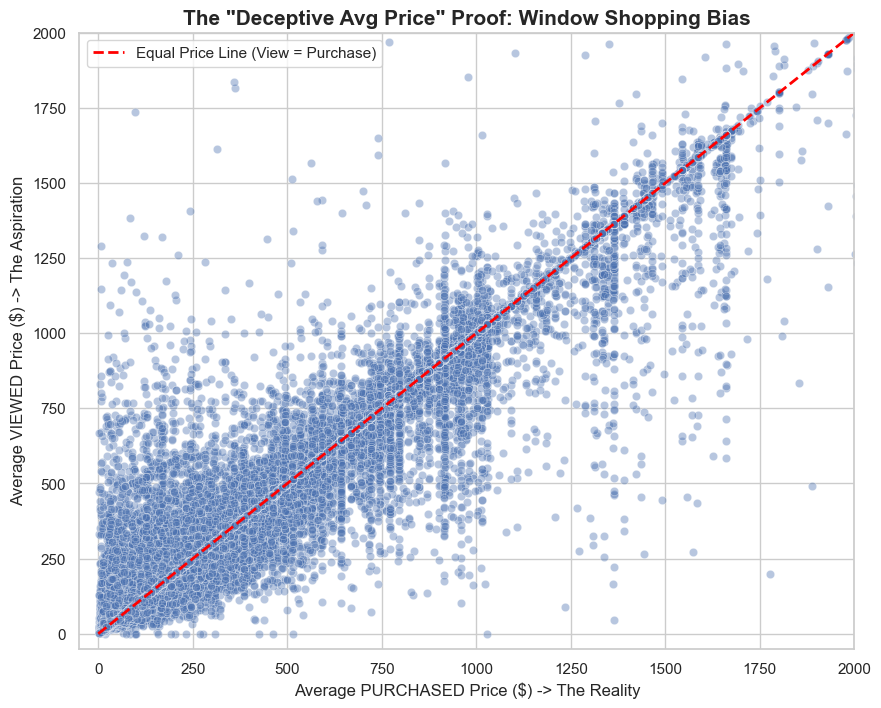

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# STEP 1: Sirf un sessions ko nikalna jahan actually purchase hua hai
purchase_sessions = final_df[final_df['event_type'] == 'purchase']['user_session'].unique()
buyers_data = final_df[final_df['user_session'].isin(purchase_sessions)]

# STEP 2: Har session ke liye average 'view' price aur average 'purchase' price nikalna
# Pivot table automatically data ko columns mein split kar degi
price_compare = buyers_data.pivot_table(
    index='user_session', 
    columns='event_type', 
    values='price', 
    aggfunc='mean'
)

# Sirf wo sessions rakhna jahan user ne view aur purchase DONO kiya hai
price_compare = price_compare.dropna(subset=['view', 'purchase'])

# STEP 3: Aapki hypothesis ka exact Percentage Test
price_compare['viewed_more_expensive'] = price_compare['view'] > price_compare['purchase']
deceptive_count = price_compare['viewed_more_expensive'].sum()
total_valid_buyers = len(price_compare)
deceptive_percentage = (deceptive_count / total_valid_buyers) * 100

print(f"Total Valid Buying Sessions: {total_valid_buyers}")
print(f"Sessions jahan Avg View Price > Purchase Price thi: {deceptive_count}")
print(f"Hypothesis Accuracy: {deceptive_percentage:.2f}% buyers ne apni purchase se mehengi cheezein dekhi thi!\n")

# STEP 4: The Proof Graph (Scatter Plot)
plt.figure(figsize=(10, 8))

# Ek point ka matlab ek user session hai
sns.scatterplot(x='purchase', y='view', data=price_compare, alpha=0.4, color='#4C72B0')

# Ek 45-degree Reference Line (Jahan View Price = Purchase Price)
# Jo bhi dots is line ke UPAR hain, wo aapki hypothesis ko Sahi prove karte hain!
plt.plot([0, 2000], [0, 2000], color='red', linestyle='--', linewidth=2, label='Equal Price Line (View = Purchase)')

plt.title('The "Deceptive Avg Price" Proof: Window Shopping Bias', fontsize=15, fontweight='bold')
plt.xlabel('Average PURCHASED Price ($) -> The Reality', fontsize=12)
plt.ylabel('Average VIEWED Price ($) -> The Aspiration', fontsize=12)

# Zoom in karke dekhne ke liye (kyunki mostly items $2000 se saste hote hain)
plt.xlim(-50, 2000)
plt.ylim(-50, 2000)
plt.legend()
plt.show()

Hypothesis check ki jo cart mein push karta h vo hi khareedhta h na ki directly khareedh leta h!

In [21]:
# STEP 1: Un sabhi unique sessions ki list (Set) banaiye jahan Purchase hua hai
purchase_sessions = set(final_df[final_df['event_type'] == 'purchase']['user_session'])

# STEP 2: Un sabhi unique sessions ki list (Set) banaiye jahan Cart event hua hai
cart_sessions = set(final_df[final_df['event_type'] == 'cart']['user_session'])

# STEP 3: The Proof (Set Difference)
# Un sessions ko nikaliye jo Purchase mein toh hain, par Cart mein NAHI hain
direct_buy_sessions = purchase_sessions - cart_sessions

# STEP 4: Numbers aur Percentage calculate karna
total_purchases = len(purchase_sessions)
direct_buys = len(direct_buy_sessions)
direct_buy_percentage = (direct_buys / total_purchases) * 100

print("-" * 50)
print("🔍 HYPOTHESIS TEST: The 'Direct Buy' Behavior")
print("-" * 50)
print(f"Total Sessions with a Purchase : {total_purchases}")
print(f"Sessions that BYPASSED the Cart: {direct_buys}")
print(f"Direct Buy (Buy Now) Percentage: {direct_buy_percentage:.2f}%")
print("-" * 50)

--------------------------------------------------
🔍 HYPOTHESIS TEST: The 'Direct Buy' Behavior
--------------------------------------------------
Total Sessions with a Purchase : 77447
Sessions that BYPASSED the Cart: 12504
Direct Buy (Buy Now) Percentage: 16.15%
--------------------------------------------------


Avg_Price vs actual_buying_Price:

In [22]:
import numpy as np

# STEP 1: Boolean Masks (Pehle ki tarah)
final_df['is_view'] = (final_df['event_type'] == 'view').astype(int)
final_df['is_cart'] = (final_df['event_type'] == 'cart').astype(int)
final_df['is_purchase'] = (final_df['event_type'] == 'purchase').astype(int)

# NAYA STEP: Prices ko alag-alag columns mein daalna taaki groupby mein aasaani ho
# Agar event 'view' hai toh price rakho, warna NaN kar do
final_df['view_price'] = np.where(final_df['event_type'] == 'view', final_df['price'], np.nan)
# Agar event 'cart' hai toh price rakho, warna NaN kar do
final_df['cart_price'] = np.where(final_df['event_type'] == 'cart', final_df['price'], np.nan)

# STEP 2: The UPDATED Master GroupBy
ml_dataframe = final_df.groupby('user_session').agg(
    total_views=('is_view', 'sum'),             
    total_carts=('is_cart', 'sum'),             
    unique_products=('product_id', 'nunique'),  
    
    # NAYE PRICE FEATURES (Missing values ko 0 se fill kar rahe hain)
    avg_view_price=('view_price', 'mean'),                
    avg_cart_price=('cart_price', 'mean'),
    
    start_time=('event_time', 'min'),           
    end_time=('event_time', 'max'),             
    target_purchase=('is_purchase', 'max')      
)

# Missing prices ko 0 se fill karna (agar kisi ne cart banaya hi nahi)
ml_dataframe['avg_view_price'] = ml_dataframe['avg_view_price'].fillna(0)
ml_dataframe['avg_cart_price'] = ml_dataframe['avg_cart_price'].fillna(0)

# STEP 3: Feature Engineering - Session Duration
ml_dataframe['session_duration_seconds'] = (ml_dataframe['end_time'] - ml_dataframe['start_time']).dt.total_seconds()

# STEP 4: Cleaning up 
ml_dataframe = ml_dataframe.drop(columns=['start_time', 'end_time'])
ml_dataframe = ml_dataframe.reset_index()
print("New ML Features with Split Prices:")
display(ml_dataframe.head())

New ML Features with Split Prices:


,user_session,total_views,total_carts,unique_products,avg_view_price,avg_cart_price,target_purchase,session_duration_seconds
0,00000510-834a-498a-9bed-561a90c5125e,1,0,1,69.170000,0.0,0,0.0
1,000009c4-a1dd-4764-87d9-24f3d7e43c4f,9,0,5,822.974444,0.0,0,485.0
2,0000189b-6d2d-45bc-a65c-3a9d94e330a4,1,0,1,10.180000,0.0,0,0.0
3,000029a6-1986-4a71-8139-53669c1adaba,6,0,3,362.676667,0.0,0,133.0
4,00003dca-5a5a-4af2-86ef-9851ceb02a2b,2,0,1,127.150000,0.0,0,56.0


In [1]:
ml_dataframe.sample(6)

NameError: name 'ml_dataframe' is not defined

In [34]:
ml_dataframe.to_csv('ML_dataframe.csv')

Data Preperation For ML:-

Train-test and Split with model Training:-

Training Data Shape: (1102577, 6)
Testing Data Shape:  (275645, 6)
Applying scale_pos_weight: 16.80

Training the XGBoost Model... (This might take a few seconds)
Training Complete! ✅

--------------------------------------------------
🎯 FINAL MODEL EVALUATION REPORT 🎯
--------------------------------------------------
1. Overall Accuracy Score: 90.39%

2. Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.95    260156
           1       0.36      0.91      0.51     15489

    accuracy                           0.90    275645
   macro avg       0.68      0.90      0.73    275645
weighted avg       0.96      0.90      0.92    275645



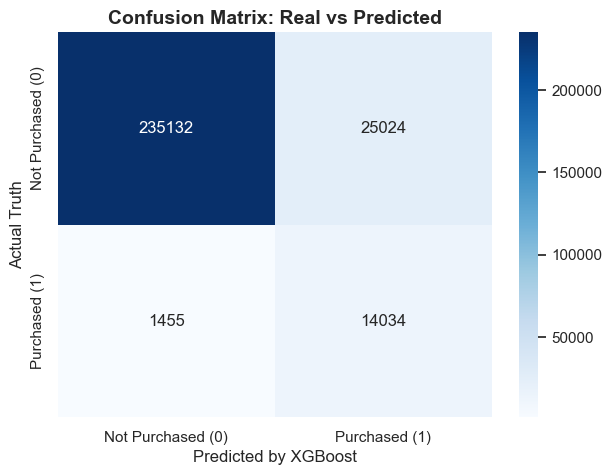

In [24]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# STEP 1: Features (X) aur Target (y) ko alag karna
# 'user_session' aur 'target_purchase' ko features se hata rahe hain
X = ml_dataframe.drop(columns=['user_session', 'target_purchase'])
y = ml_dataframe['target_purchase']

# STEP 2: Train-Test Split (80% Training, 20% Testing)
# stratify=y lagana bohot zaroori hai imbalanced data ke liye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape:  {X_test.shape}")

# STEP 3: Calculate Dynamic Imbalance Weight
# Formula: Total Zeros (Negative) / Total Ones (Positive) in Training Data
imbalance_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Applying scale_pos_weight: {imbalance_weight:.2f}\n")

# STEP 4: Model Initialize aur Train Karna
# Hum XGBoost use kar rahe hain kyunki ye tabular data ka "King" hai
xgb_model = XGBClassifier(
    scale_pos_weight=imbalance_weight, # Galti ki Saza (Penalty)
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1 # Pura CPU use karne ke liye fast training
)

print("Training the XGBoost Model... (This might take a few seconds)")
xgb_model.fit(X_train, y_train)
print("Training Complete! ✅\n")

# STEP 5: Predictions Make Karna
y_pred = xgb_model.predict(X_test)

# STEP 6: ALL ACCURACY METRICS PRINT KARNA
print("-" * 50)
print("🎯 FINAL MODEL EVALUATION REPORT 🎯")
print("-" * 50)

# 1. Overall Accuracy (Ye imbalanced data me dhokha hoti hai, ispar zyada dhyan na de)
acc = accuracy_score(y_test, y_pred)
print(f"1. Overall Accuracy Score: {acc * 100:.2f}%\n")

# 2. Classification Report (Asli test yahan hai)
print("2. Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix Plot Karna
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Purchased (0)', 'Purchased (1)'], 
            yticklabels=['Not Purchased (0)', 'Purchased (1)'])
plt.title('Confusion Matrix: Real vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Predicted by XGBoost', fontsize=12)
plt.ylabel('Actual Truth', fontsize=12)
plt.show()

Cross_Validation:-

--------------------------------------------------
⚙️ PHASE 1: CROSS-VALIDATION (Checking Stability)
--------------------------------------------------
Cross-Validation AUC Scores: [0.96129818 0.96040982 0.95979739]
Average CV AUC Score: 0.9605 (Model ki asli consistency!)

--------------------------------------------------
🔍 PHASE 2: THRESHOLD TUNING & ROC-AUC CURVE
--------------------------------------------------
Default Threshold (0.50) F1-Score: 0.51
🔥 OPTIMAL THRESHOLD: 0.8767
🔥 NEW BEST F1-SCORE: 0.5934

--------------------------------------------------
📈 PHASE 3: FINAL CLASSIFICATION REPORT (At Threshold = 0.8767)
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.96      0.97    260156
           1       0.50      0.74      0.59     15489

    accuracy                           0.94    275645
   macro avg       0.74      0.85      0.78    275645
weighted avg       0.96      0.94      0.95  

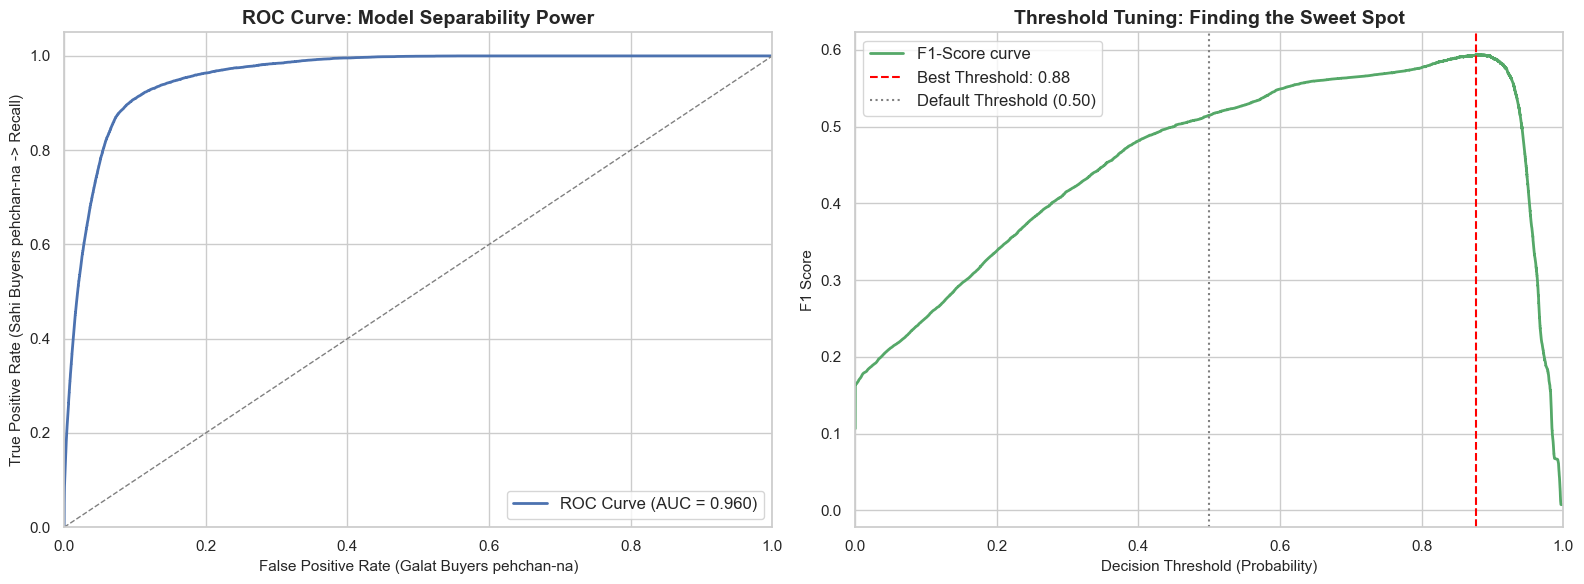

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, classification_report # <-- Added classification_report

sns.set_theme(style="whitegrid")

print("-" * 50)
print("⚙️ PHASE 1: CROSS-VALIDATION (Checking Stability)")
print("-" * 50)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_auc_scores = cross_val_score(xgb_model, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"Cross-Validation AUC Scores: {cv_auc_scores}")
print(f"Average CV AUC Score: {cv_auc_scores.mean():.4f} (Model ki asli consistency!)\n")


print("-" * 50)
print("🔍 PHASE 2: THRESHOLD TUNING & ROC-AUC CURVE")
print("-" * 50)

y_probs = xgb_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_probs)

f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_pr[optimal_idx]
best_f1 = f1_scores[optimal_idx]

print(f"Default Threshold (0.50) F1-Score: 0.51") 
print(f"🔥 OPTIMAL THRESHOLD: {optimal_threshold:.4f}")
print(f"🔥 NEW BEST F1-SCORE: {best_f1:.4f}\n")


print("-" * 50)
print(f"📈 PHASE 3: FINAL CLASSIFICATION REPORT (At Threshold = {optimal_threshold:.4f})")
print("-" * 50)

# MAGIC STEP: Naye threshold ke hisaab se probabilities ko 0 ya 1 mein convert karna
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal))


# 📊 GRAPHS PLOT KARNA (Interview Visuals)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--') 
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (Galat Buyers pehchan-na)', fontsize=11)
ax1.set_ylabel('True Positive Rate (Sahi Buyers pehchan-na -> Recall)', fontsize=11)
ax1.set_title('ROC Curve: Model Separability Power', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=12)

ax2.plot(thresholds_pr, f1_scores[:-1], color='#55A868', lw=2, label='F1-Score curve')
ax2.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Best Threshold: {optimal_threshold:.2f}')
ax2.axvline(x=0.5, color='gray', linestyle=':', label='Default Threshold (0.50)')

ax2.set_xlim([0.0, 1.0])
ax2.set_xlabel('Decision Threshold (Probability)', fontsize=11)
ax2.set_ylabel('F1 Score', fontsize=11)
ax2.set_title('Threshold Tuning: Finding the Sweet Spot', fontsize=14, fontweight='bold')
ax2.legend(loc="best", fontsize=12)

plt.tight_layout()
plt.show()

F2-Score:-


------------------------------------------------------------
⚙️ PHASE 1: CROSS-VALIDATION (Checking Stability)
------------------------------------------------------------
Cross-Validation AUC Scores: [0.96129818 0.96040982 0.95979739]
Average CV AUC Score: 0.9605 (Model ki asli consistency!)

------------------------------------------------------------
🔍 PHASE 2: THRESHOLD TUNING (Optimized for RECALL via F2-Score)
------------------------------------------------------------
🔥 OPTIMAL THRESHOLD (For High Recall): 0.6784
🔥 MAX F2-SCORE ACHIEVED: 0.7140

------------------------------------------------------------
📈 PHASE 3: FINAL CLASSIFICATION REPORT (At Threshold = 0.6784)
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.93      0.96    260156
           1       0.42      0.87      0.56     15489

    accuracy                           0.92    275645
   macro avg       0.70      0.90    

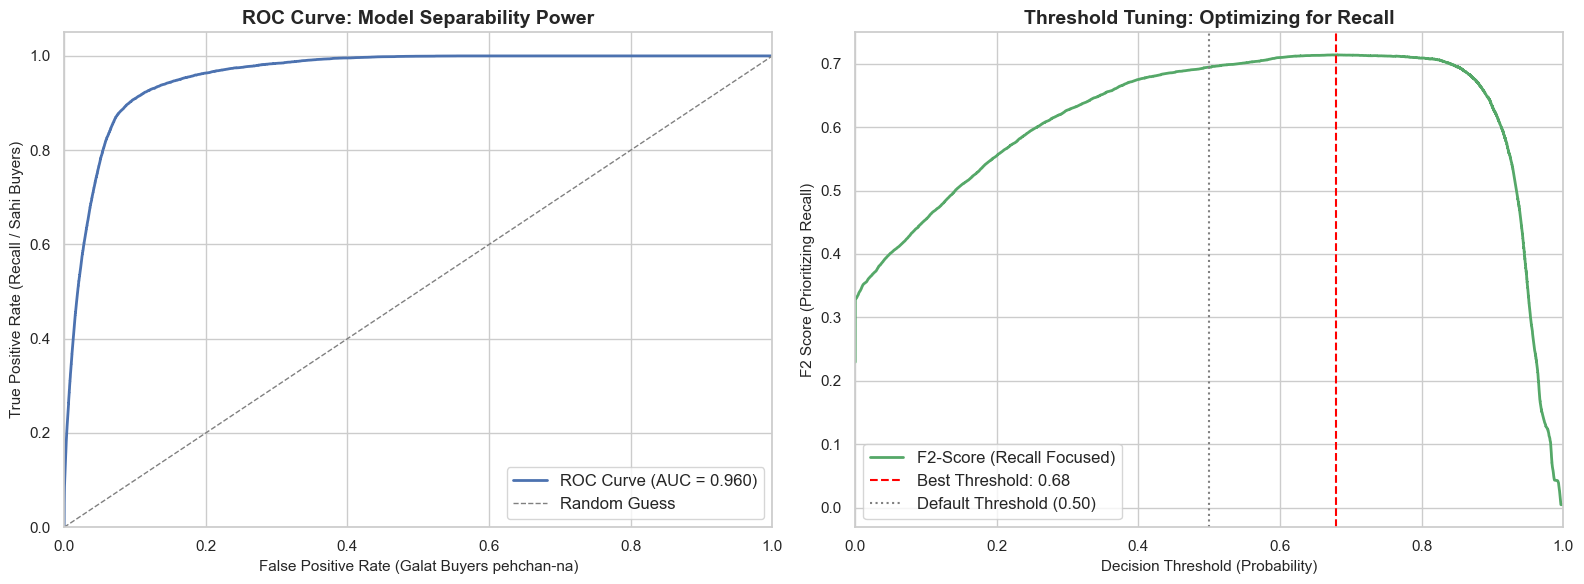

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, classification_report

# Graph ki theme set kar rahe hain
sns.set_theme(style="whitegrid")

print("-" * 60)
print("⚙️ PHASE 1: CROSS-VALIDATION (Checking Stability)")
print("-" * 60)
# 3 Folds mein data ko test karke model ki consistency check karna
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_auc_scores = cross_val_score(xgb_model, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"Cross-Validation AUC Scores: {cv_auc_scores}")
print(f"Average CV AUC Score: {cv_auc_scores.mean():.4f} (Model ki asli consistency!)\n")


print("-" * 60)
print("🔍 PHASE 2: THRESHOLD TUNING (Optimized for RECALL via F2-Score)")
print("-" * 60)

# Model se har user ke kharidne ki Probability (0 to 1) nikalna
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# 1. ROC Curve ke points nikalna
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 2. Precision-Recall aur Thresholds nikalna
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_probs)

# MAGIC STEP: F2-Score calculate karna (Recall is 2x more important than Precision)
beta = 2
f2_scores = np.divide((1 + beta**2) * (precisions * recalls), 
                      ((beta**2 * precisions) + recalls), 
                      out=np.zeros_like(precisions), 
                      where=((beta**2 * precisions) + recalls) != 0)

# Sabse maximum F2-Score aur uska threshold dhoondhna
optimal_idx = np.argmax(f2_scores)
optimal_threshold_f2 = thresholds_pr[optimal_idx]
best_f2 = f2_scores[optimal_idx]

print(f"🔥 OPTIMAL THRESHOLD (For High Recall): {optimal_threshold_f2:.4f}")
print(f"🔥 MAX F2-SCORE ACHIEVED: {best_f2:.4f}\n")


print("-" * 60)
print(f"📈 PHASE 3: FINAL CLASSIFICATION REPORT (At Threshold = {optimal_threshold_f2:.4f})")
print("-" * 60)

# Naye Threshold ke hisaab se probabilities ko 0 ya 1 mein badalna
y_pred_optimal = (y_probs >= optimal_threshold_f2).astype(int)

# Nayi aur better Report Print karna
print(classification_report(y_test, y_pred_optimal))


# ==========================================
# 📊 PHASE 4: INTERVIEW-READY VISUALIZATIONS
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPH 1: ROC-AUC CURVE ---
ax1.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess') 
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (Galat Buyers pehchan-na)', fontsize=11)
ax1.set_ylabel('True Positive Rate (Recall / Sahi Buyers)', fontsize=11)
ax1.set_title('ROC Curve: Model Separability Power', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=12)

# --- GRAPH 2: F2-SCORE vs THRESHOLD CURVE ---
# F2 Scores ko plot karna har threshold ke against
ax2.plot(thresholds_pr, f2_scores[:-1], color='#55A868', lw=2, label='F2-Score (Recall Focused)')
ax2.axvline(x=optimal_threshold_f2, color='red', linestyle='--', label=f'Best Threshold: {optimal_threshold_f2:.2f}')
ax2.axvline(x=0.5, color='gray', linestyle=':', label='Default Threshold (0.50)')

ax2.set_xlim([0.0, 1.0])
ax2.set_xlabel('Decision Threshold (Probability)', fontsize=11)
ax2.set_ylabel('F2 Score (Prioritizing Recall)', fontsize=11)
ax2.set_title('Threshold Tuning: Optimizing for Recall', fontsize=14, fontweight='bold')
ax2.legend(loc="best", fontsize=12)

plt.tight_layout()
plt.show()

Hyperparamter Tuning:-

In [28]:
import numpy as np
import time
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

print("-" * 60)
print("⚙️ PHASE 1: SETTING UP THE PENALTY & PARAMETER GRID")
print("-" * 60)

# 1. Penalty calculate karna (Taaki Model 1s ko miss na kare)
imbalance_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Strict Penalty Applied (scale_pos_weight): {imbalance_weight:.2f}")

# 2. Hyperparameters ka "Menu" banana
# XGBoost in values me se best combination dhoondhega
param_grid = {
    'n_estimators': [100, 200, 300],         # Kitne trees (ped) ugane hain
    'max_depth': [3, 5, 7],                  # Har tree kitna deep hoga (Complexity)
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Model kitni jaldi/dheere seekhega
    'subsample': [0.7, 0.8, 1.0],            # Overfitting rokne ke liye kitna % data use kare
    'colsample_bytree': [0.7, 0.8, 1.0]      # Har tree mein kitne % features (columns) bhejein
}

# 3. Base Model Initialize karna (Penalty ke sath)
xgb_base = XGBClassifier(
    scale_pos_weight=imbalance_weight, 
    random_state=42,
    n_jobs=-1 # CPU ke saare cores use karne ke liye
)

print("\n" + "-" * 60)
print("🚀 PHASE 2: STARTING CROSS-VALIDATED HYPERPARAMETER TUNING")
print("-" * 60)

# 4. Stratified K-Fold (Taaki har fold mein 2% buyers safely maintain rahein)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 5. RandomizedSearchCV Setup
# Hum 'roc_auc' ko maximize karne ko bol rahe hain taaki 0 aur 1 ke beech clear separation ho
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,             # 10 random combinations try karega (Time bachane ke liye)
    scoring='roc_auc',     # Imbalanced data ke liye best CV scoring metric
    cv=skf,                # 3-Fold Cross Validation
    verbose=2,             # Progress bar dikhane ke liye
    random_state=42,
    n_jobs=-1              # Parallel processing
)

print("Starting training... (Grab a coffee, this might take 5-15 minutes depending on CPU)\n")
start_time = time.time()

# Model ko sikhana shuru karo
random_search.fit(X_train, y_train)

end_time = time.time()
print(f"\n✅ Tuning Completed in {(end_time - start_time)/60:.2f} minutes!")


print("\n" + "-" * 60)
print("🏆 PHASE 3: THE WINNING HYPERPARAMETERS 🏆")
print("-" * 60)

# 6. Best parameters aur score print karna
best_params = random_search.best_params_
for param, value in best_params.items():
    print(f"-> {param}: {value}")

print(f"\n🌟 Best Cross-Validated ROC-AUC Score: {random_search.best_score_:.4f}")

# 7. Naya "Champion" Model save karna
best_xgb_model = random_search.best_estimator_

# Note: Ab aage ki saari predictions aap is 'best_xgb_model' se kar sakte hain!

------------------------------------------------------------
⚙️ PHASE 1: SETTING UP THE PENALTY & PARAMETER GRID
------------------------------------------------------------
Strict Penalty Applied (scale_pos_weight): 16.80

------------------------------------------------------------
🚀 PHASE 2: STARTING CROSS-VALIDATED HYPERPARAMETER TUNING
------------------------------------------------------------
Starting training... (Grab a coffee, this might take 5-15 minutes depending on CPU)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Tuning Completed in 1.97 minutes!

------------------------------------------------------------
🏆 PHASE 3: THE WINNING HYPERPARAMETERS 🏆
------------------------------------------------------------
-> subsample: 1.0
-> n_estimators: 200
-> max_depth: 7
-> learning_rate: 0.05
-> colsample_bytree: 1.0

🌟 Best Cross-Validated ROC-AUC Score: 0.9611


------------------------------------------------------------
⚙️ CALCULATING OPTIMAL THRESHOLD FOR CHAMPION MODEL
------------------------------------------------------------
🔥 Naya Optimal Threshold (Tuned Model ke liye): 0.7339

------------------------------------------------------------
🏆 FINAL CHAMPION MODEL EVALUATION REPORT 🏆
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.93      0.96    260156
           1       0.43      0.86      0.57     15489

    accuracy                           0.93    275645
   macro avg       0.71      0.90      0.77    275645
weighted avg       0.96      0.93      0.94    275645



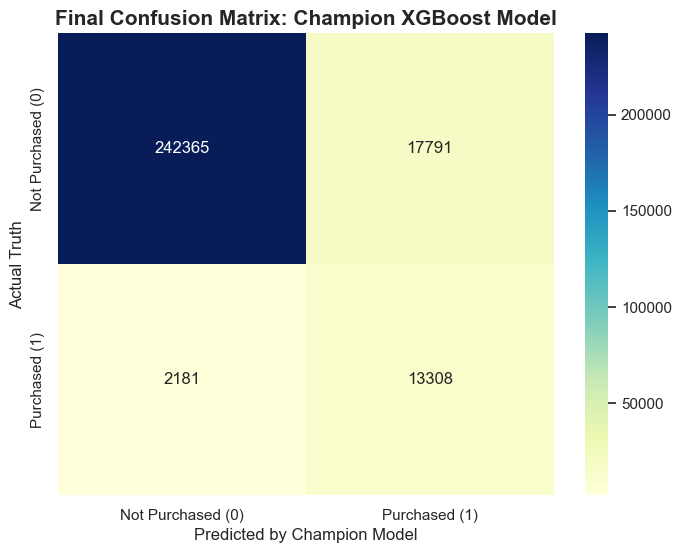

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import numpy as np

print("-" * 60)
print("⚙️ CALCULATING OPTIMAL THRESHOLD FOR CHAMPION MODEL")
print("-" * 60)

# 1. Naye Champion Model se probabilities nikalna
y_probs_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

# 2. Re-calculating the F2 optimal threshold for this newly tuned model
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_tuned)
beta = 2
f2_scores = np.divide((1 + beta**2) * (precisions * recalls), 
                      ((beta**2 * precisions) + recalls), 
                      out=np.zeros_like(precisions), 
                      where=((beta**2 * precisions) + recalls) != 0)

optimal_idx = np.argmax(f2_scores)
optimal_threshold_tuned = thresholds[optimal_idx]

print(f"🔥 Naya Optimal Threshold (Tuned Model ke liye): {optimal_threshold_tuned:.4f}\n")

# 3. Final Predictions with the optimal threshold
y_pred_final = (y_probs_tuned >= optimal_threshold_tuned).astype(int)

# 4. Classification Report
print("-" * 60)
print("🏆 FINAL CHAMPION MODEL EVALUATION REPORT 🏆")
print("-" * 60)
print(classification_report(y_test, y_pred_final))

# 5. Confusion Matrix Plot (Naye aur behtar colors ke sath)
cm_tuned = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
# YlGnBu colormap professional presentations ke liye best hota hai
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Not Purchased (0)', 'Purchased (1)'], 
            yticklabels=['Not Purchased (0)', 'Purchased (1)'])

plt.title('Final Confusion Matrix: Champion XGBoost Model', fontsize=15, fontweight='bold')
plt.xlabel('Predicted by Champion Model', fontsize=12)
plt.ylabel('Actual Truth', fontsize=12)
plt.show()